In [39]:

!pip install -U transformers datasets peft accelerate bitsandbytes sentencepiece
!pip install -U evaluate rouge-score


In [40]:

import os, math, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset, Dataset, DatasetDict
from transformers import (AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig,
                          TrainingArguments, Trainer, DataCollatorForLanguageModeling)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
import torch

csv_path = "/content/filtered_abstractive_summarization.csv"
source_column = "content"
target_column = "summary"


context_window = 1024
max_target_tokens = 120

seed = 42
torch.backends.cuda.matmul.allow_tf32 = True
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print("CUDA available:", torch.cuda.is_available())


CUDA available: True


In [41]:

# Load CSV to DataFrame for cleaning/EDA
df = pd.read_csv(csv_path ,on_bad_lines='skip' , nrows= 25000)

def normalize_text(s):
    if not isinstance(s, str):
        return ""
    s = s.replace("\r\n", "\n").replace("\r", "\n")
    s = " ".join(s.split())
    return s.strip()

df[source_column] = df[source_column].apply(normalize_text)
df[target_column] = df[target_column].apply(normalize_text)

before = len(df)
df = df.dropna(subset=[source_column, target_column])
df = df[df[source_column].str.len() > 0]
df = df[df[target_column].str.len() > 0]
df = df.drop_duplicates(subset=[source_column]).reset_index(drop=True)
after = len(df)
print(f"Rows before: {before} -> after cleaning: {after}")

# Save a cleaned interim CSV (optional)
clean_path = "abstractive_summarization.cleaned.csv"
df.to_csv(clean_path, index=False)
print("Saved cleaned CSV to:", clean_path)

raw = Dataset.from_pandas(df)
split = raw.train_test_split(test_size=0.1, seed=42)
ds = DatasetDict({"train": split["train"], "validation": split["test"]})
print(ds)


Rows before: 25000 -> after cleaning: 25000
Saved cleaned CSV to: abstractive_summarization.cleaned.csv
DatasetDict({
    train: Dataset({
        features: ['content', 'summary', 'content_token_length', 'summary_token_length'],
        num_rows: 22500
    })
    validation: Dataset({
        features: ['content', 'summary', 'content_token_length', 'summary_token_length'],
        num_rows: 2500
    })
})


In [42]:
print(df.sample(1))

                                                content  \
6868  CTCP Chứng khoán Golden Bridge Việt Nam (GBS) ...   

                                                summary  content_token_length  \
6868  Tháng 7/2012 đã có gần 10 công ty chứng khoán ...                   291   

      summary_token_length  
6868                   140  


In [ ]:
import os
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

        "from dotenv import load_dotenv\n",
        "load_dotenv()\n",
        "\n",
        "HF_TOKEN = os.environ.get('HF_TOKEN')\n",
        "if not HF_TOKEN:\n",
        "    raise ValueError('HF_TOKEN not set. Please configure it in .env file')\n"

In [44]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "meta-llama/Llama-3.2-1B",
    use_fast=False,
    token=HF_TOKEN,
)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"


In [45]:
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

model_id = "meta-llama/Llama-3.2-1B"

bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_cfg,
    device_map="auto",
    torch_dtype=torch.bfloat16,
    attn_implementation="sdpa",
    token=HF_TOKEN,
)


In [46]:
import pandas as pd
from datasets import Dataset, DatasetDict

tokenizer.padding_side = "right"
tokenizer.pad_token = tokenizer.eos_token

prompt_prefix = "Hãy tóm tắt ngắn gọn và súc tích đoạn văn sau:\n"
prompt_suffix = "\n\nTóm tắt: "

def token_length(text):
    return len(tokenizer(text, add_special_tokens=False).input_ids)

def compute_len_table(dset, max_rows=20000):
    rows = []
    n = min(len(dset), max_rows)
    for i in range(n):
        ex = dset[i]
        rows.append({
            "idx": i,
            "src_len_tokens": token_length(ex[source_column]),
            "tgt_len_tokens": token_length(ex[target_column]),
        })
    return pd.DataFrame(rows)

train_len_df = compute_len_table(ds["train"])
print(train_len_df[["src_len_tokens","tgt_len_tokens"]].describe(percentiles=[0.5,0.9,0.95]))

context_window = 1024
max_target_tokens = 256

prompt_tokens_est = token_length(prompt_prefix + prompt_suffix)
src_q95 = int(train_len_df["src_len_tokens"].quantile(0.95))
budget_for_source = max(1, context_window - (prompt_tokens_est + max_target_tokens + 1))
max_source_tokens = min(src_q95, budget_for_source)

print("prompt_tokens:", prompt_tokens_est)
print("budget_for_source:", budget_for_source)
print("max_source_tokens:", max_source_tokens)

def build_prompt_source(s):
    return f"{prompt_prefix}{s}{prompt_suffix}"

def format_example(ex):
    return {"source_text": str(ex[source_column]).strip(),
            "target_text": str(ex[target_column]).strip()}

formatted = ds.map(format_example, remove_columns=ds["train"].column_names)

def tokenize_with_caps(batch):
    input_ids, attention_mask, labels = [], [], []
    for src, tgt in zip(batch["source_text"], batch["target_text"]):
        ps = tokenizer(build_prompt_source(src), add_special_tokens=False).input_ids[:budget_for_source]
        tg = tokenizer(tgt, add_special_tokens=False).input_ids[:max_target_tokens] + [tokenizer.eos_token_id]
        ids = ps + tg
        input_ids.append(ids)
        attention_mask.append([1]*len(ids))
        labels.append([-100]*len(ps) + tg)
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}

tokenized = formatted.map(tokenize_with_caps, batched=True, remove_columns=formatted["train"].column_names)
print(tokenized)


       src_len_tokens  tgt_len_tokens
count    20000.000000    20000.000000
mean       419.787850      139.577150
std        158.937393       40.187026
min        150.000000       50.000000
50%        403.000000      135.000000
90%        656.000000      197.000000
95%        700.000000      215.000000
max        750.000000      250.000000
prompt_tokens: 20
budget_for_source: 747
max_source_tokens: 700


Map:   0%|          | 0/22500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/22500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 22500
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 2500
    })
})


- context_window: tổng “sức chứa” token cho 1 lần (prompt + source + target + EOS).
- max_target_tokens: số token tối đa dành cho summary (nhãn) khi chuẩn bị dữ liệu.

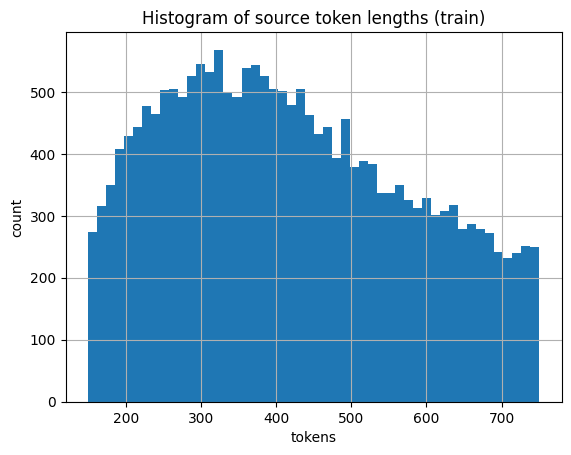

In [47]:

plt.figure()
train_len_df["src_len_tokens"].hist(bins=50)
plt.title("Histogram of source token lengths (train)")
plt.xlabel("tokens")
plt.ylabel("count")
plt.show()


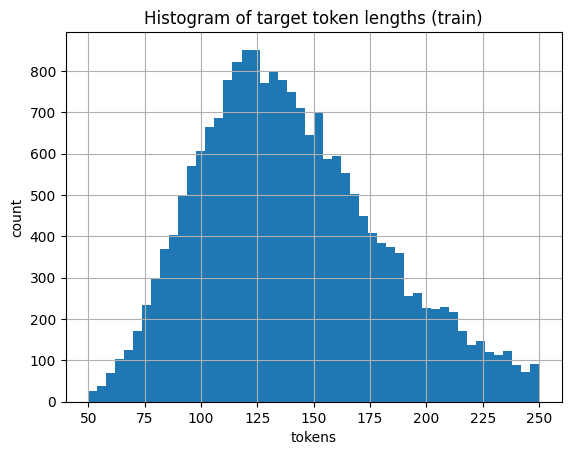

In [48]:

# Histogram for target token lengths (train)
plt.figure()
train_len_df["tgt_len_tokens"].hist(bins=50)
plt.title("Histogram of target token lengths (train)")
plt.xlabel("tokens")
plt.ylabel("count")
plt.show()


In [49]:

def build_prompt_source(src_text):
    return f"{prompt_prefix}{src_text}{prompt_suffix}"

def format_example(example):
    src = str(example[source_column]).strip()
    tgt = str(example[target_column]).strip()
    return {"source_text": src, "target_text": tgt}

formatted = ds.map(format_example, remove_columns=[c for c in ds["train"].column_names if c not in [source_column, target_column]])

def tokenize_with_caps(batch):
    input_ids_list = []
    attention_masks = []
    label_ids_list = []

    for src, tgt in zip(batch["source_text"], batch["target_text"]):
        # Tokenize prompt+source (no target)
        prompt_source = build_prompt_source(src)
        ps_ids = tokenizer(prompt_source, add_special_tokens=False).input_ids

        # Reserve (max_target_tokens + 1 eos) for target
        max_ps = max(1, context_window - (max_target_tokens + 1))
        ps_ids = ps_ids[:max_ps]

        # Tokenize target + eos
        tgt_ids = tokenizer(tgt, add_special_tokens=False).input_ids
        tgt_ids = tgt_ids[:max_target_tokens]
        tgt_ids = tgt_ids + [tokenizer.eos_token_id]

        # Concatenate
        full_ids = ps_ids + tgt_ids
        attn = [1] * len(full_ids)

        # Labels: -100 for prompt+source tokens; predict only on target
        labels = [-100] * len(ps_ids) + tgt_ids.copy()

        input_ids_list.append(full_ids)
        attention_masks.append(attn)
        label_ids_list.append(labels)

    return {"input_ids": input_ids_list, "attention_mask": attention_masks, "labels": label_ids_list}

tokenized = formatted.map(tokenize_with_caps, batched=True, remove_columns=formatted["train"].column_names)
print(tokenized)


Map:   0%|          | 0/22500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/22500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 22500
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 2500
    })
})


In [50]:
import os, gc, torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

# dọn VRAM để tránh auto-offload
gc.collect(); torch.cuda.empty_cache()
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

model_id = "meta-llama/Llama-3.2-1B"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    token=HF_TOKEN,                           # repo gated
    quantization_config=bnb_config,
    device_map={"": 0},                       # ÉP toàn bộ lên cuda:0 (không auto-offload)
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,                   # giảm RAM host khi load
    attn_implementation="sdpa",
)


In [51]:
lora_r = 16
lora_alpha = 16
lora_dropout =0.3

lora_cfg = LoraConfig(
    r=lora_r,
    lora_alpha=lora_alpha,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=lora_dropout,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(model, lora_cfg)
print(model.print_trainable_parameters())

trainable params: 3,407,872 || all params: 1,239,222,272 || trainable%: 0.2750
None


In [52]:
!pip install -U transformers


In [55]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
import torch
from peft import get_peft_model

def causal_collator(batch):
    max_len = max(len(ex["input_ids"]) for ex in batch)
    pad_id = tokenizer.pad_token_id
    input_ids, attention_mask, labels = [], [], []
    for ex in batch:
        ids, mask, labs = ex["input_ids"], ex["attention_mask"], ex["labels"]
        pad = max_len - len(ids)
        input_ids.append(ids + [pad_id]*pad)
        attention_mask.append(mask + [0]*pad)
        labels.append(labs + [-100]*pad)
    return {
        "input_ids": torch.tensor(input_ids),
        "attention_mask": torch.tensor(attention_mask),
        "labels": torch.tensor(labels),
    }

if not hasattr(model, "peft_config"):
    model = get_peft_model(model, lora_cfg)

run_name = "llama32_1b_vi_sum_lora"

args = TrainingArguments(
    output_dir=run_name,
    per_device_train_batch_size=12,
    gradient_accumulation_steps=1,
    learning_rate=1e-4,
    num_train_epochs=10,
    logging_steps=200,

    eval_strategy="epoch",
    report_to="none",
    bf16=True, fp16=False,
    optim="adamw_torch_fused",
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    remove_unused_columns=False,
    group_by_length=True,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    weight_decay=0.02,
    max_grad_norm=0.3,

    save_strategy = "epoch",
    load_best_model_at_end = True,
    metric_for_best_model = "eval_loss",
)

model.gradient_checkpointing_enable()
model.enable_input_require_grads()

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    data_collator=causal_collator,
    tokenizer=tokenizer,
    callbacks=[ EarlyStoppingCallback(early_stopping_patience=3) ]
)

# train
trainer.train()

adapter_dir = run_name + "_adapter"
model.save_pretrained(adapter_dir)
tokenizer.save_pretrained(adapter_dir)




/tmp/ipython-input-270319421.py:55: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 128001}.


Epoch,Training Loss,Validation Loss
1,0.387100,0.381805
2,0.364400,0.364840
3,0.334800,0.358589
4,0.320500,0.357954
5,0.305000,0.358957


/usr/local/lib/python3.12/dist-packages/peft/utils/other.py:1394: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-6919c095-5ed95eb2602c658215870988;37ab329c-9632-4f48-8a94-02ea1cb509c9)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.2-1B/resolve/main/config.json.
Access to model meta-llama/Llama-3.2-1B is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in meta-llama/Llama-3.2-1B.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:295: UserWarning: Could not find a config file in meta-llama/Llama-3.2-1B - will assume that the vocabulary was not modified.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/other.py:1394: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-6919c44d-288ae75a0ae4b8f71962323f

Epoch,Training Loss,Validation Loss
1,0.387100,0.381805
2,0.364400,0.364840
3,0.334800,0.358589
4,0.320500,0.357954
5,0.305000,0.358957
6,0.285200,0.362041
7,0.273500,0.366090


/usr/local/lib/python3.12/dist-packages/peft/utils/other.py:1394: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-6919d331-2f00f8b223ceea3c2226d1f3;af30a096-c2b7-4ebf-919e-f7337d83e244)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.2-1B/resolve/main/config.json.
Access to model meta-llama/Llama-3.2-1B is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in meta-llama/Llama-3.2-1B.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:295: UserWarning: Could not find a config file in meta-llama/Llama-3.2-1B - will assume that the vocabulary was not modified.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/other.py:1394: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-6919d6eb-3d7482b1136f861c573bf8ad

('llama32_1b_vi_sum_lora_adapter/tokenizer_config.json',
 'llama32_1b_vi_sum_lora_adapter/special_tokens_map.json',
 'llama32_1b_vi_sum_lora_adapter/tokenizer.json')

In [56]:

example_text = ds["validation"][0][source_column] if len(ds["validation"]) > 0 else ds["train"][0][source_column]
prompt = f"{prompt_prefix}{example_text}{prompt_suffix}"
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
with torch.no_grad():
    out = model.generate(**inputs, max_new_tokens=max_target_tokens, temperature=0.7, top_p=0.9, do_sample=True)
print(tokenizer.decode(out[0], skip_special_tokens=True))


Hãy tóm tắt ngắn gọn và súc tích đoạn văn sau:
Nguyễn Hà Đông - tác giả trò chơi Flappy Bird đình đám - vừa tung ra Ninja Spinki Challenges, một trò chơi khác với độ khó cực cao. Trong trò chơi này, Hà Đông liên kết với công ty Obokaidem từ Nhật Bản. Họ hi vọng trò chơi tiếp tục khiến người dùng nổi điên với độ khó trong khi không thể dứt ra. Hiện, Ninja Spinki Challenges đã có mặt trên cả Android và iOS. Trò chơi bao gồm 6 thử thách mini với nhân vật Ninja Spinki. Nhân vật này từng được giới thiệu ở game Swing Copters trước đây. Venture Beat cho biết người chơi gần như không thể chiến thắng trong game này. Cách chơi của game mới vẫn tương tự Flappy Bird, nhưng yêu cầu độ chính xác tuyệt đối và canh chỉnh thời gian hoàn hảo để vượt qua những màn đầu tiên. Màn chơi thử thách có 6 chế độ. Mỗi màn chơi có 2 chế độ, thử thách hoặc sinh tồn. Để chơi, bạn cần chạm màn hình hoặc vẽ các đường đúng lúc để tránh vật cản. Nếu qua màn, bạn sẽ mở khóa các tầng chơi và biểu tượng khác. Các thử thách

In [57]:
!zip -r llama32_1b_vi_sum_lora_checkpoints.zip llama32_1b_vi_sum_lora
!zip -r llama32_1b_vi_sum_lora_adapter.zip llama32_1b_vi_sum_lora_adapter

  adding: llama32_1b_vi_sum_lora/ (stored 0%)
  adding: llama32_1b_vi_sum_lora/checkpoint-1000/ (stored 0%)
  adding: llama32_1b_vi_sum_lora/checkpoint-1000/README.md (deflated 65%)
  adding: llama32_1b_vi_sum_lora/checkpoint-1000/scheduler.pt (deflated 61%)
  adding: llama32_1b_vi_sum_lora/checkpoint-1000/tokenizer.json (deflated 85%)
  adding: llama32_1b_vi_sum_lora/checkpoint-1000/adapter_model.safetensors (deflated 8%)
  adding: llama32_1b_vi_sum_lora/checkpoint-1000/tokenizer_config.json (deflated 96%)
  adding: llama32_1b_vi_sum_lora/checkpoint-1000/rng_state.pth (deflated 26%)
  adding: llama32_1b_vi_sum_lora/checkpoint-1000/optimizer.pt (deflated 8%)
  adding: llama32_1b_vi_sum_lora/checkpoint-1000/trainer_state.json (deflated 65%)
  adding: llama32_1b_vi_sum_lora/checkpoint-1000/special_tokens_map.json (deflated 64%)
  adding: llama32_1b_vi_sum_lora/checkpoint-1000/adapter_config.json (deflated 58%)
  adding: llama32_1b_vi_sum_lora/checkpoint-1000/training_args.bin (deflated 5